In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage import data
from skimage.util import random_noise, img_as_float64
from skimage.metrics import peak_signal_noise_ratio, mean_squared_error

from scipy.ndimage import gaussian_filter, median_filter

In [3]:
def load_image(image_path):
    if os.path.exists(image_path):
        image = Image.open(image_path).convert('L')
        image_array = np.array(image)
        return img_as_float64(image_array)
    return img_as_float64(data.camera())

def add_gaussian_noise(image, std_dev):
    var = (std_dev / 255)**2
    noisy_image = random_noise(image, mode='gaussian', clip=True, var=var)
    return noisy_image

def plot_orginal_and_noisy(original_image, noisy_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Sa šumom')
    plt.axis('off')

def denoise_gaussian_filter(image, std_dev):
    return gaussian_filter(image, sigma=std_dev)

def denoise_median_filter(image, size):
    return median_filter(image, size=size)

def forward_gradient(u):
    gx = np.zeros_like(u)
    gy = np.zeros_like(u)
    gx[:, :-1] = u[:, 1:] - u[:, :-1]
    gy[:-1, :] = u[1:, :] - u[:-1, :]
    return gx, gy

def divergence(px, py):
    div = np.zeros_like(px)
    div[:, 0] = px[:, 0]
    div[:, 1:] = px[:, 1:] - px[:, :-1]
    div[0, :] += py[0, :]
    div[1:, :] += py[1:, :] - py[:-1, :]
    return div

def chambolle_projection(f, lam, dt=0.248, tol=1e-2, max_iter=5000, p=None):
    px = np.zeros_like(f) if p is None else p[0].copy()
    py = np.zeros_like(f) if p is None else p[1].copy()

    for _ in range(max_iter):
        gx, gy = forward_gradient(divergence(px, py) - lam * f)
        norm = np.sqrt(gx * gx + gy * gy)
        denom = 1.0 + dt * norm
        px_new = (px + dt * gx) / denom
        py_new = (py + dt * gy) / denom
        change = max(np.max(np.abs(px_new - px)), np.max(np.abs(py_new - py)))
        px, py = px_new, py_new
        if change <= tol:
            break

    u = np.clip(f - divergence(px, py) / lam, 0.0, 1.0)
    return u, (px, py)

def denoise_tv(noisy_image, std_dev=20, n_outer=5):
    sigma = std_dev / 255.0
    n = np.sqrt(noisy_image.size)
    lam = (2.1237 / std_dev + 2.0547 / (std_dev ** 2)) * 255.0
    p = None
    u = noisy_image
    for _ in range(n_outer):
        u, p = chambolle_projection(noisy_image, lam, p=p)
        residual = np.linalg.norm(u - noisy_image)
        lam = lam * residual / (n * sigma)
    return u

In [4]:
def compare(*images):

    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(img_num, 2, i + 1)
        plt.imshow(images[2*i], cmap='gray')
        plt.title(images[2*i + 1])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def plot_signal(*images):

    row = original_image.shape[0] // 2
    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(img_num, 2, 2*i + 1)
        plt.imshow(images[2*i], cmap='gray')
        plt.title(images[2*i + 1])
        plt.axis('off')

        plt.subplot(img_num, 2, 2*i + 2)
        plt.plot(images[2*i][row, :], color='blue', linewidth=1.5)
        plt.title(images[2*i + 1])
        plt.grid(True, alpha=0.3)
        plt.ylim([0, 1])

    plt.tight_layout()
    plt.show()

RMSE / PSNR (data_range=1)
šum             RMSE=0.0777  PSNR=22.20 dB
Gauss           RMSE=0.0503  PSNR=25.97 dB
Median          RMSE=0.0354  PSNR=29.02 dB
Chambolle TV    RMSE=0.0258  PSNR=31.76 dB


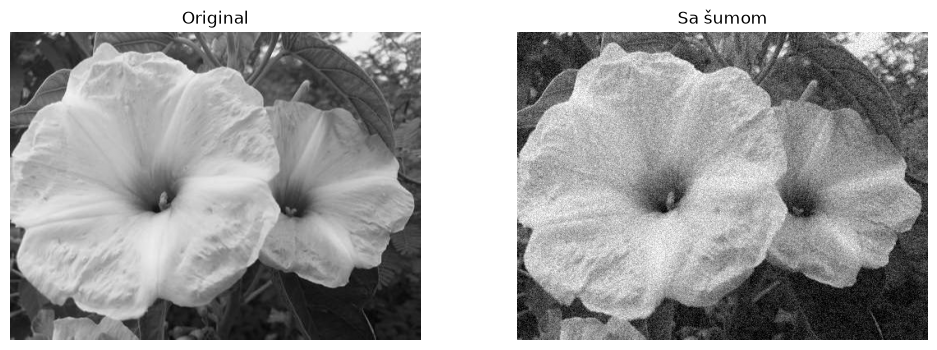

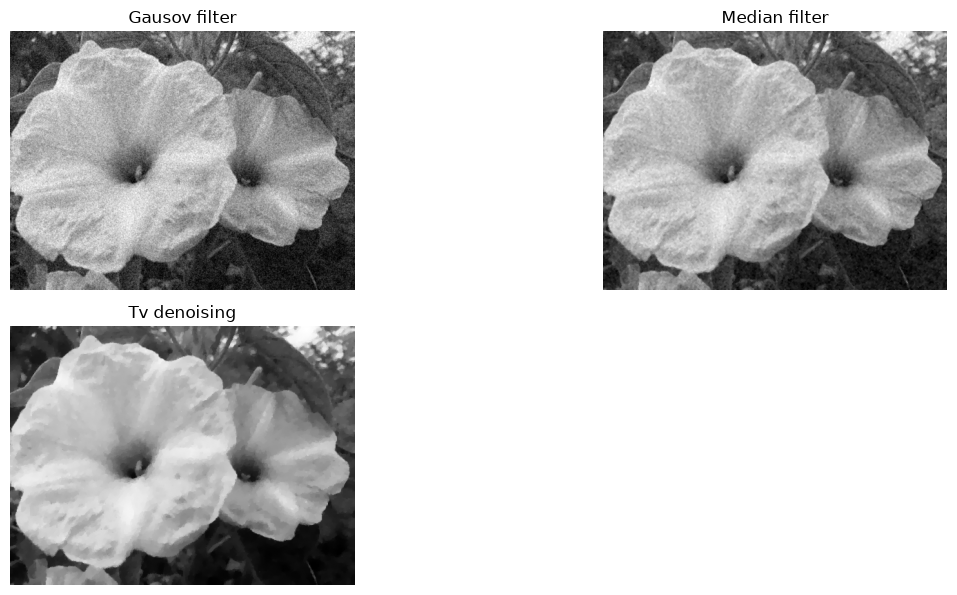

In [5]:
original_image = load_image('flowers.jpg')

noisy_image = add_gaussian_noise(original_image, 20)

gaussian_denoised = denoise_gaussian_filter(noisy_image, 0.5)

median_denoised = denoise_median_filter(noisy_image, 3)

tv_denoised = denoise_tv(noisy_image, 20)

print('RMSE / PSNR (data_range=1)')
for name, img in [
    ('šum', noisy_image),
    ('Gauss', gaussian_denoised),
    ('Median', median_denoised),
    ('Chambolle TV', tv_denoised),
]:
    err = np.sqrt(mean_squared_error(original_image, img))
    print(f'{name:14s}  RMSE={err:.4f}  PSNR={peak_signal_noise_ratio(original_image, img, data_range=1.0):.2f} dB')

plot_orginal_and_noisy(original_image, noisy_image)

compare(gaussian_denoised, 'Gausov filter', median_denoised, 'Median filter', tv_denoised, 'Tv denoising')

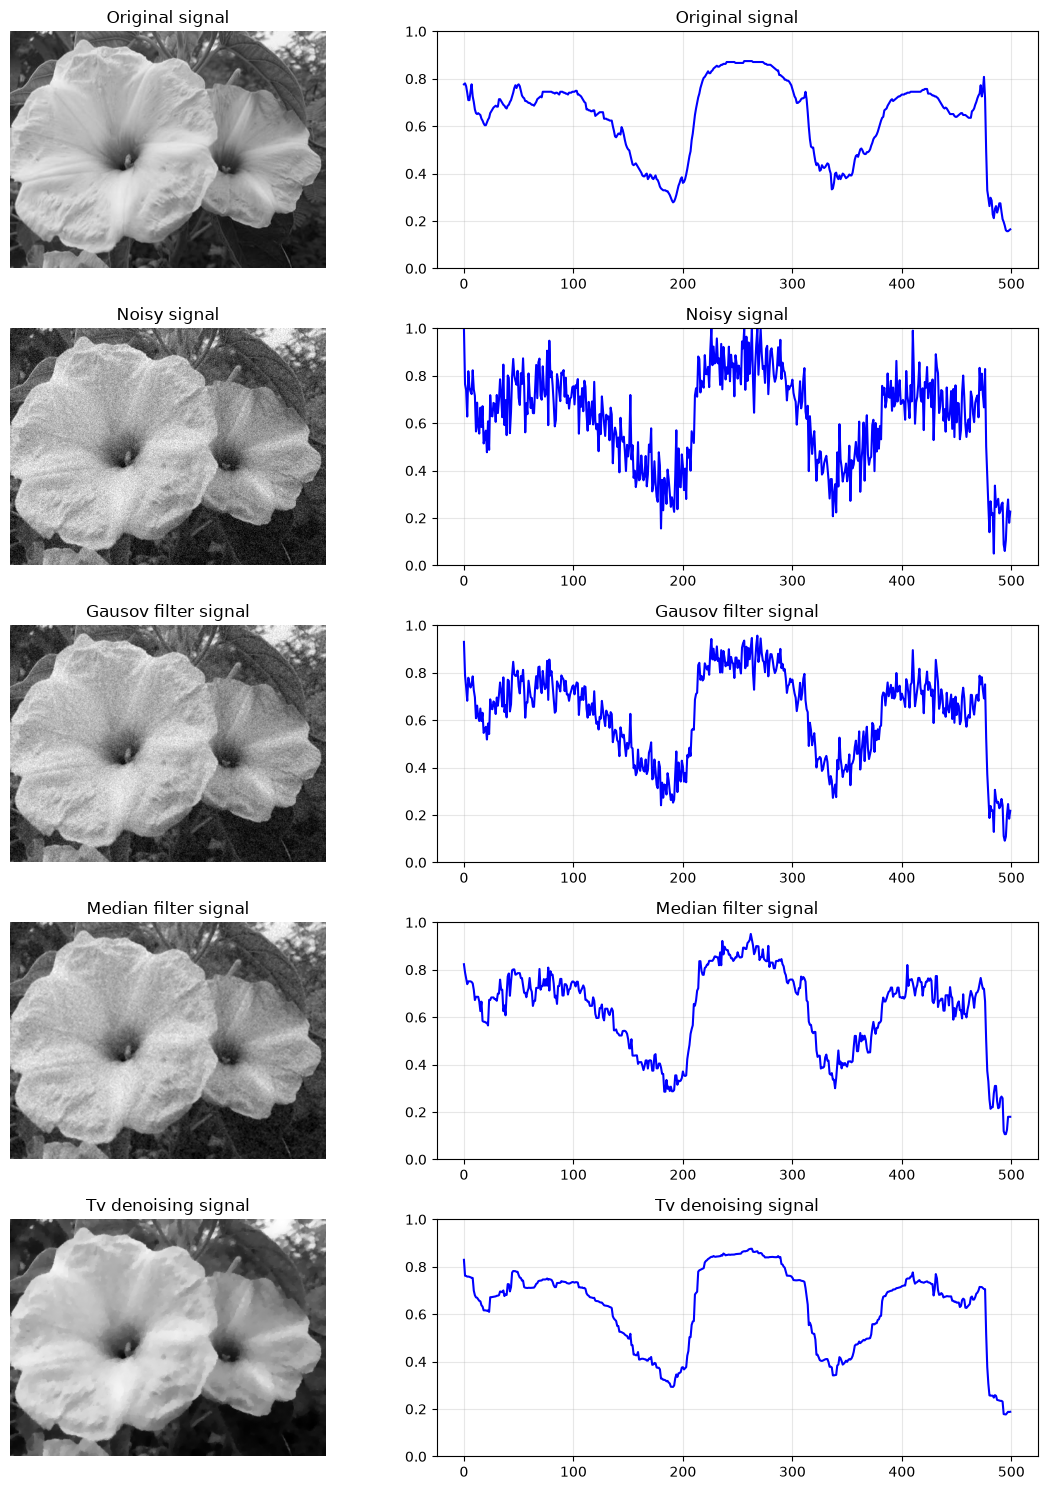

In [6]:
plot_signal(original_image,'Original signal', noisy_image, 'Noisy signal', gaussian_denoised, \
            'Gausov filter signal', median_denoised, 'Median filter signal', tv_denoised, 'Tv denoising signal')